Data collection & loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")

Data cleaning & EDA

In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [5]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [6]:
df.shape

(6607, 20)

In [7]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [8]:
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0])
df['Distance_from_Home'] = df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0])
df['Teacher_Quality'] = df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])

In [9]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
target_variable = 'Exam_Score'
numerical_features = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
categorical_features = ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

In [12]:
for col in numerical_features:
    if col != target_variable:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)
        df[col] = np.clip(df[col], lower_bound, upper_bound)

<Axes: ylabel='Hours_Studied'>

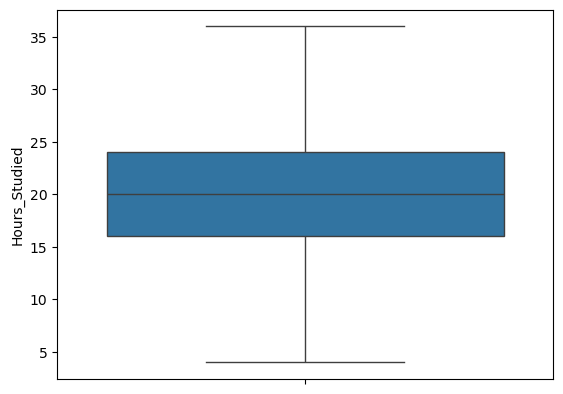

In [13]:
sns.boxplot(df['Hours_Studied'])

<Axes: ylabel='Tutoring_Sessions'>

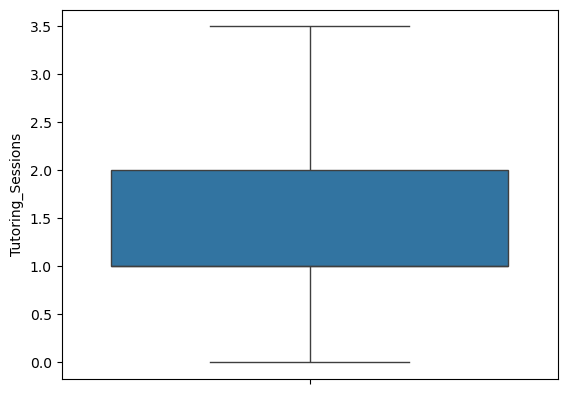

In [14]:
sns.boxplot(df['Tutoring_Sessions'])

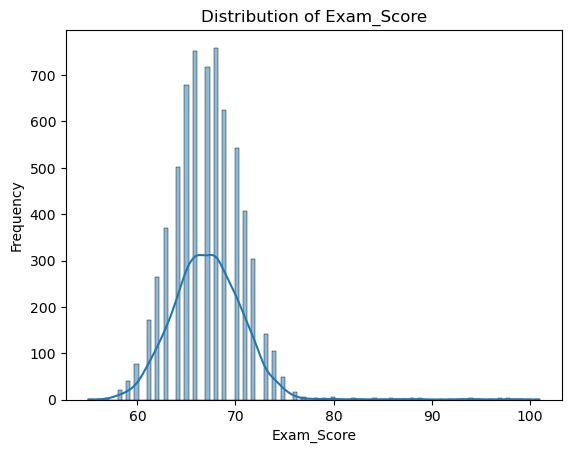

In [15]:
sns.histplot(df[target_variable], kde=True)
plt.title(f'Distribution of {target_variable}')
plt.xlabel(target_variable)
plt.ylabel('Frequency')
plt.show()

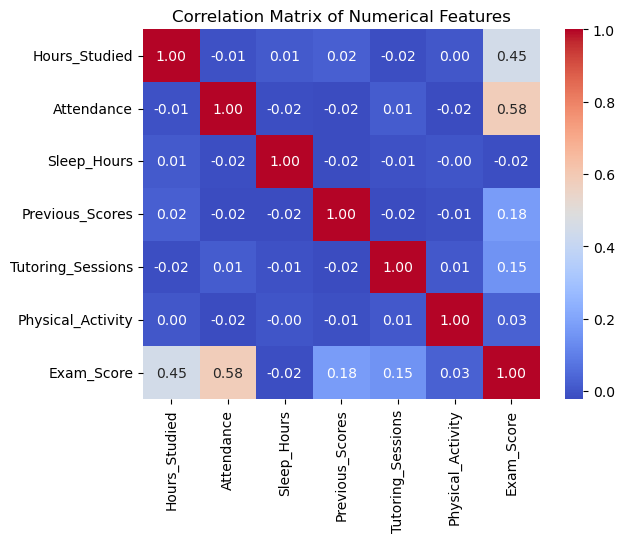

In [16]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Feature Engineering

In [17]:
X = df.drop(target_variable, axis=1)
y = df[target_variable]

categorical_cols = X.select_dtypes(include='object').columns

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_encoded_cols = X_encoded.columns.tolist()

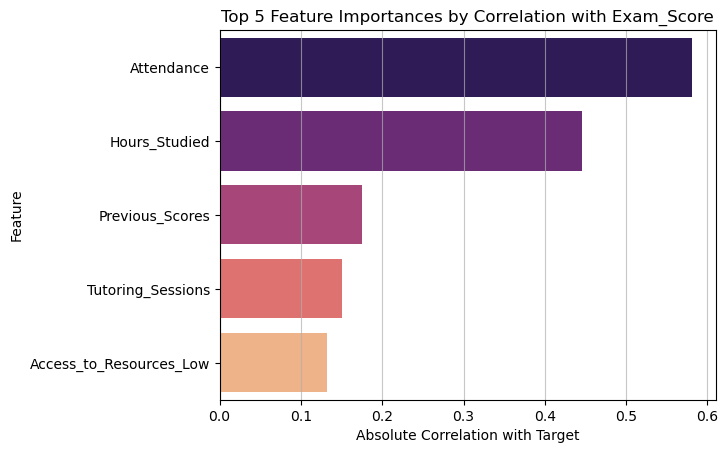

In [18]:
combined_df = X_encoded.copy()
combined_df[target_variable] = y

n = 5

correlation_with_target = combined_df.corr()[target_variable].drop(target_variable).abs()

importance_df_corr = pd.DataFrame({
    'Feature': correlation_with_target.index,
    'Importance': correlation_with_target.values
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

sns.barplot(x='Importance', y='Feature', data=importance_df_corr.head(n), palette='magma', hue='Feature')
plt.title(f'Top {n} Feature Importances by Correlation with {target_variable}')
plt.xlabel('Absolute Correlation with Target')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.7)
plt.show()

Train–test split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

Model selection

In [20]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

X_test_scaled = scaler_X.transform(X_test)

Model Training

In [21]:
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
svr_model.fit(X_train_scaled, y_train_scaled)

y_pred_scaled = svr_model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

Evalutaion Metrics

In [22]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"\nSVR Initial Model Performance")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")


SVR Initial Model Performance
Mean Squared Error (MSE): 3.38
Root Mean Squared Error (RMSE): 1.84
Mean Absolute Error (MAE): 0.51


Hyperparameter Tuning

In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'epsilon': [0.01, 0.1, 0.5]
}

grid_search = GridSearchCV(
    estimator=svr_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error', 
    cv=5,                           
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train_scaled)

best_params = grid_search.best_params_
best_score = grid_search.best_score_ 

best_rmse = np.sqrt(abs(best_score))

print("\nHyperparameter Tuning Results")
print(f"Best Parameters found: {best_params}")
print(f"Best CV RMSE: {best_rmse:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits


Final Model Selection

In [ ]:
final_svr_model = SVR(
    kernel='rbf',
    C=best_params['C'],
    epsilon=best_params['epsilon'],
    gamma=best_params['gamma']
)

final_svr_model.fit(X_train_scaled, y_train_scaled)

y_final_pred_scaled = final_svr_model.predict(X_test_scaled)

y_final_pred = scaler_y.inverse_transform(y_final_pred_scaled.reshape(-1, 1)).flatten()

final_mse = mean_squared_error(y_test, y_final_pred)
final_rmse = np.sqrt(final_mse)
final_mae = mean_absolute_error(y_test, y_final_pred) 

print("\nFinal Optimized SVR Model Performance on Test Set")
print(f"Final Mean Squared Error (MSE): {final_mse:.2f}")
print(f"Final Root Mean Squared Error (RMSE): {final_rmse:.2f}")
print(f"Final Mean Absolute Error (MAE): {final_mae:.2f}") 

Visualization

In [ ]:
sns.scatterplot(x=y_test, y=y_final_pred, alpha=0.6)

min_val = min(y_test.min(), y_final_pred.min())
max_val = max(y_test.max(), y_final_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Final Model: Actual vs. Predicted Target Values')
plt.xlabel(f'Actual {target_variable}')
plt.ylabel(f'Predicted {target_variable}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()